# Data Preprocessing and EDA Pipeline

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('cleaned.csv')
df.head()

,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Lanes_or_Medians,Types_of_Junction,Road_surface_type,Light_conditions,Weather_conditions,Type_of_collision,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Accident_severity
0,18-30,Male,Above high school,Employee,1-2yr,Unknown,No junction,Asphalt roads,Daylight,Normal,Collision with roadside-parked vehicles,Going straight,Not a Pedestrian,Moving Backward,2
1,31-50,Male,Junior high school,Employee,Above 10yr,Undivided Two way,No junction,Asphalt roads,Daylight,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Overtaking,2
2,18-30,Male,Junior high school,Employee,1-2yr,other,No junction,Asphalt roads,Daylight,Normal,Collision with roadside objects,Going straight,Not a Pedestrian,Changing lane to the left,1
3,18-30,Male,Junior high school,Employee,5-10yr,other,Y Shape,Earth roads,Darkness - lights lit,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Changing lane to the right,2
4,18-30,Male,Junior high school,Employee,2-5yr,other,Y Shape,Asphalt roads,Darkness - lights lit,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Overtaking,2


## 1. Missing Data Checking and Handling

This section loads the dataset and performs initial data exploration to identify missing values and understand the data structure.

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age_band_of_driver       12316 non-null  str  
 1   Sex_of_driver            12316 non-null  str  
 2   Educational_level        12316 non-null  str  
 3   Vehicle_driver_relation  12316 non-null  str  
 4   Driving_experience       12316 non-null  str  
 5   Lanes_or_Medians         12316 non-null  str  
 6   Types_of_Junction        12316 non-null  str  
 7   Road_surface_type        12316 non-null  str  
 8   Light_conditions         12316 non-null  str  
 9   Weather_conditions       12316 non-null  str  
 10  Type_of_collision        12316 non-null  str  
 11  Vehicle_movement         12316 non-null  str  
 12  Pedestrian_movement      12316 non-null  str  
 13  Cause_of_accident        12316 non-null  str  
 14  Accident_severity        12316 non-null  int64
dtypes: int64(1), 

In [13]:
df.isnull()

,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Lanes_or_Medians,Types_of_Junction,Road_surface_type,Light_conditions,Weather_conditions,Type_of_collision,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Accident_severity
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12312,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12313,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12314,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
print("\nUnique values in key columns:")
print(df['Age_band_of_driver'].unique())


Unique values in key columns:
<StringArray>
['18-30', '31-50', 'Under 18', 'Over 51', 'Unknown']
Length: 5, dtype: str


In [15]:
print(df['Driving_experience'].unique())

<StringArray>
[     '1-2yr', 'Above 10yr',     '5-10yr',      '2-5yr',    'Unknown',
 'No Licence',  'Below 1yr',    'unknown']
Length: 8, dtype: str


In [16]:
print(df['Lanes_or_Medians'].unique())

<StringArray>
[                                         'Unknown',
                                'Undivided Two way',
                                            'other',
                      'Double carriageway (median)',
                                          'One way',
  'Two-way (divided with solid lines road marking)',
 'Two-way (divided with broken lines road marking)']
Length: 7, dtype: str


In [17]:
print(df['Road_surface_type'].unique())

<StringArray>
[                   'Asphalt roads',                      'Earth roads',
                          'Unknown', 'Asphalt roads with some distress',
                     'Gravel roads',                            'Other']
Length: 6, dtype: str


In [18]:
print(df['Accident_severity'].unique())

[2 1 0]


In [19]:
df.duplicated().sum()



np.int64(390)

## 2. Duplicate Data Checking and Handling

Duplicate rows are identified and removed to ensure data integrity. Unique values in key columns are examined to detect any possible entity mismatches.

In [20]:
df = df.drop_duplicates()
df.duplicated().sum()




np.int64(0)

## 3. Encoding Approach for Categorical Features

Categorical features are encoded using appropriate methods. Ordinal features with natural ordering are mapped to numeric values. Nominal features are transformed using one-hot encoding to avoid imposing artificial ordering.

In [21]:
nominal = [
    "Sex_of_driver", "Vehicle_driver_relation", "Lanes_or_Medians",
    "Types_of_Junction", "Road_surface_type", "Light_conditions",
    "Weather_conditions", "Type_of_collision", "Vehicle_movement",
    "Pedestrian_movement", "Cause_of_accident"
]

ordinal = [
    "Age_band_of_driver", "Educational_level",
    "Driving_experience", "Accident_severity"
]

discrete = ["Accident_severity"]
continuous = []

levels_df = pd.DataFrame({
    "Nominal": pd.Series(nominal),
    "Ordinal": pd.Series(ordinal),
    "Discrete": pd.Series(discrete),
    "Continuous": pd.Series(continuous)
})

levels_df


,Nominal,Ordinal,Discrete,Continuous
0,Sex_of_driver,Age_band_of_driver,Accident_severity,NaN
1,Vehicle_driver_relation,Educational_level,NaN,NaN
2,Lanes_or_Medians,Driving_experience,NaN,NaN
3,Types_of_Junction,Accident_severity,NaN,NaN
4,Road_surface_type,NaN,NaN,NaN
5,Light_conditions,NaN,NaN,NaN
6,Weather_conditions,NaN,NaN,NaN
7,Type_of_collision,NaN,NaN,NaN
8,Vehicle_movement,NaN,NaN,NaN
9,Pedestrian_movement,NaN,NaN,NaN


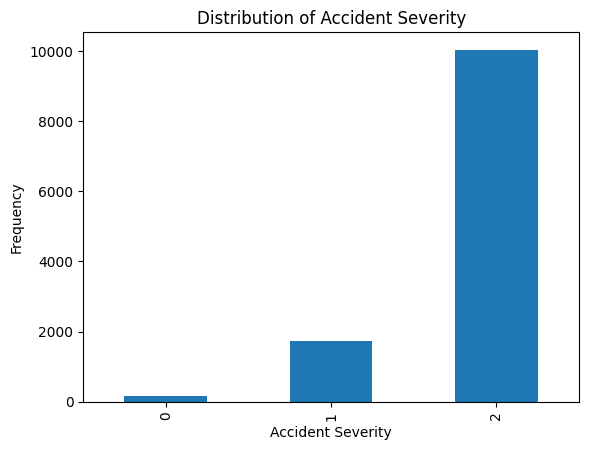

In [23]:
plt.figure()
df["Accident_severity"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Accident Severity")
plt.ylabel("Frequency")
plt.title("Distribution of Accident Severity")
plt.show()


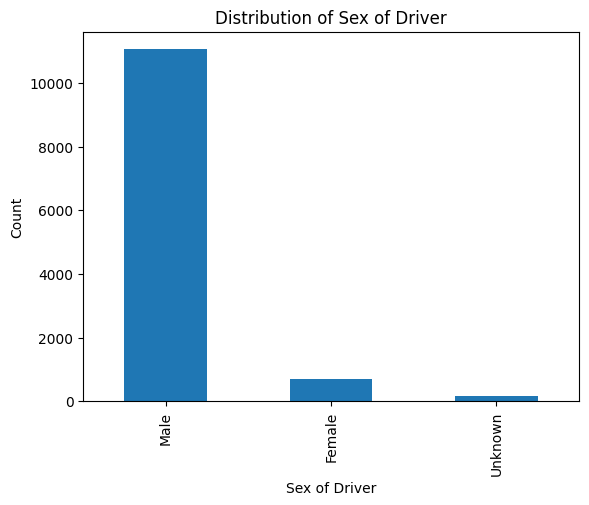

In [ ]:
plt.figure()
df['Sex_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Sex of Driver")
plt.ylabel("Count")
plt.title("Distribution of Sex of Driver")
plt.show()


In [ ]:
inexperienced = df[df["Driving_experience"].isin(["No Licence", "Below 1yr"])]
experienced = df[df["Driving_experience"].isin(["Above 10yr", "5-10yr"])]
print("Inexperienced Drivers Count:", len(inexperienced))
print("Experienced Drivers Count:", len(experienced))


Inexperienced Drivers Count: 1430
Experienced Drivers Count: 5434


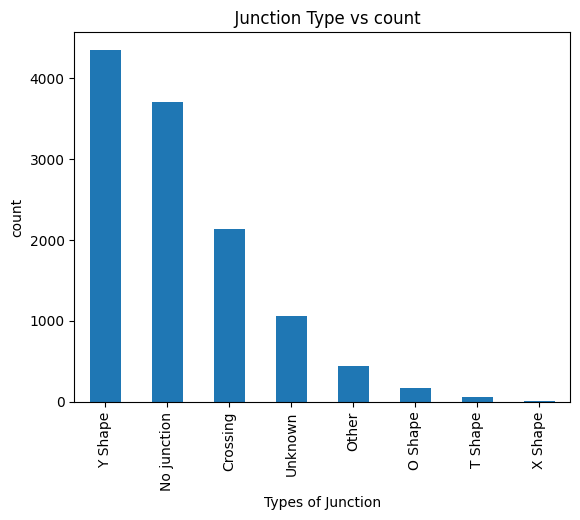

In [ ]:
plt.figure()
df['Types_of_Junction'].value_counts().plot(kind='bar')
plt.xlabel("Types of Junction")
plt.ylabel("count")
plt.title("  Junction Type vs count")
plt.show()


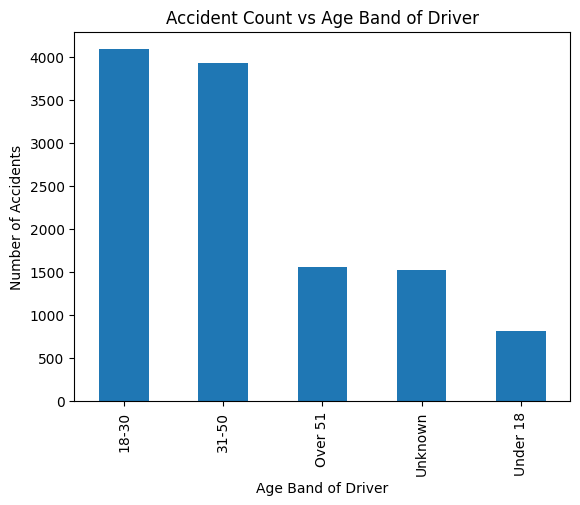

In [ ]:
plt.figure()
df['Age_band_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Age Band of Driver")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Age Band of Driver")
plt.show()


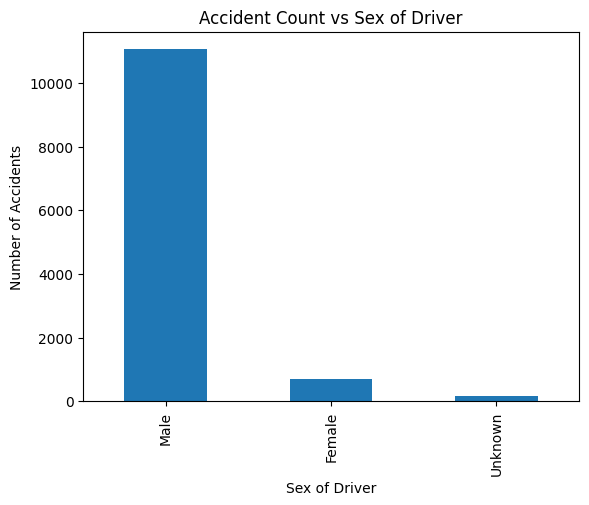

In [ ]:
plt.figure()
df['Sex_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Sex of Driver")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Sex of Driver")
plt.show()


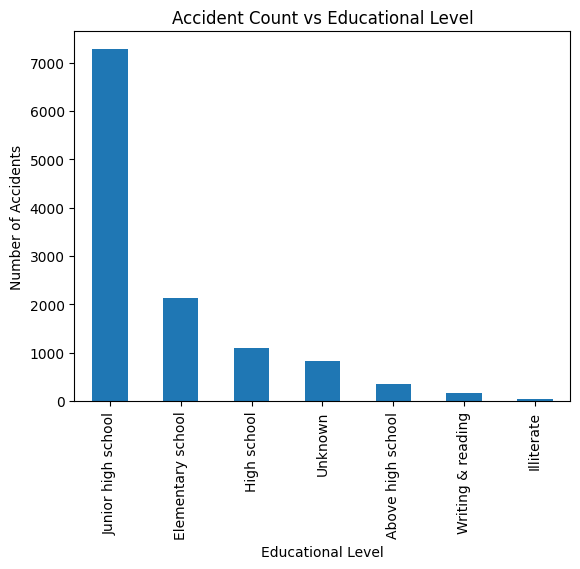

In [ ]:
plt.figure()
df['Educational_level'].value_counts().plot(kind='bar')
plt.xlabel("Educational Level")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Educational Level")
plt.show()


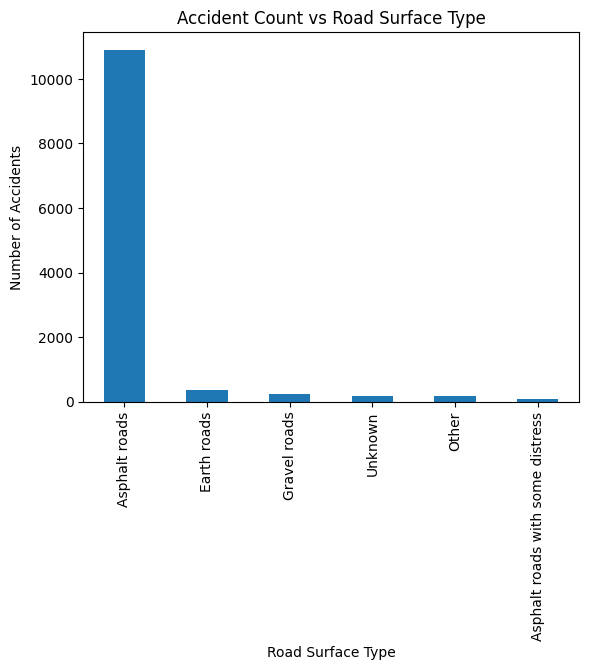

In [ ]:
plt.figure()
df['Road_surface_type'].value_counts().plot(kind='bar')
plt.xlabel("Road Surface Type")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Road Surface Type")
plt.show()


In [ ]:
df.shape


(11926, 15)

In [ ]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col])

## 4. Basic Exploratory Data Analysis

Exploratory Data Analysis includes descriptive statistics and visualizations of both numerical and categorical features. Distribution analysis helps identify patterns and anomalies in the data before modeling.

In [24]:
nominal = [
    "Sex_of_driver", "Vehicle_driver_relation", "Lanes_or_Medians",
    "Types_of_Junction", "Road_surface_type", "Light_conditions",
    "Weather_conditions", "Type_of_collision", "Vehicle_movement",
    "Pedestrian_movement", "Cause_of_accident"
]

ordinal = [
    "Age_band_of_driver", "Educational_level",
    "Driving_experience", "Accident_severity"
]

discrete = ["Accident_severity"]
continuous = []

levels_df = pd.DataFrame({
    "Nominal": pd.Series(nominal),
    "Ordinal": pd.Series(ordinal),
    "Discrete": pd.Series(discrete),
    "Continuous": pd.Series(continuous)
})

levels_df


,Nominal,Ordinal,Discrete,Continuous
0,Sex_of_driver,Age_band_of_driver,Accident_severity,NaN
1,Vehicle_driver_relation,Educational_level,NaN,NaN
2,Lanes_or_Medians,Driving_experience,NaN,NaN
3,Types_of_Junction,Accident_severity,NaN,NaN
4,Road_surface_type,NaN,NaN,NaN
5,Light_conditions,NaN,NaN,NaN
6,Weather_conditions,NaN,NaN,NaN
7,Type_of_collision,NaN,NaN,NaN
8,Vehicle_movement,NaN,NaN,NaN
9,Pedestrian_movement,NaN,NaN,NaN


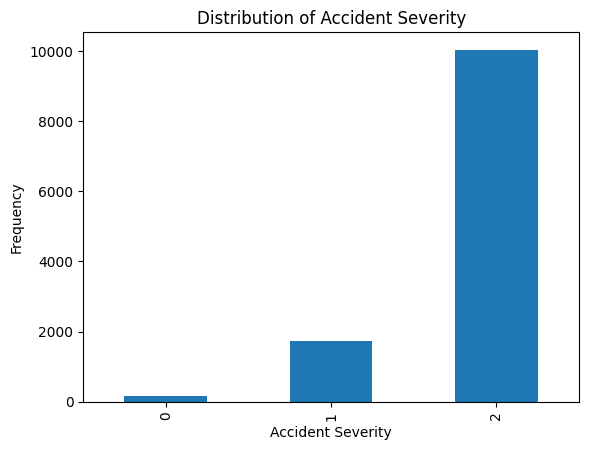

In [26]:
plt.figure()
df["Accident_severity"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Accident Severity")
plt.ylabel("Frequency")
plt.title("Distribution of Accident Severity")
plt.show()


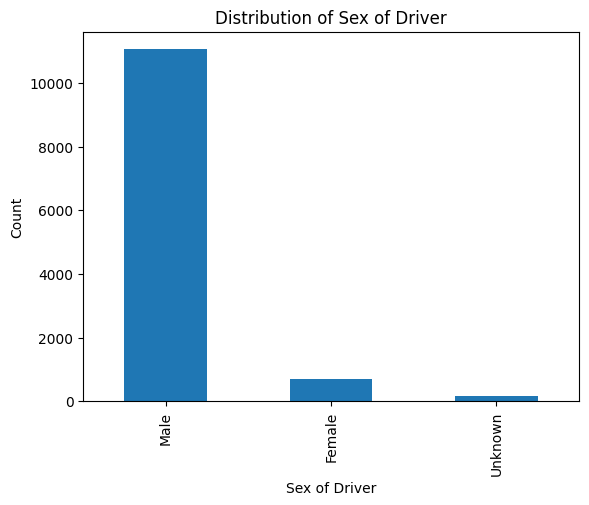

In [27]:
plt.figure()
df['Sex_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Sex of Driver")
plt.ylabel("Count")
plt.title("Distribution of Sex of Driver")
plt.show()


In [28]:
inexperienced = df[df["Driving_experience"].isin(["No Licence", "Below 1yr"])]
experienced = df[df["Driving_experience"].isin(["Above 10yr", "5-10yr"])]
print("Inexperienced Drivers Count:", len(inexperienced))
print("Experienced Drivers Count:", len(experienced))


Inexperienced Drivers Count: 1430
Experienced Drivers Count: 5434


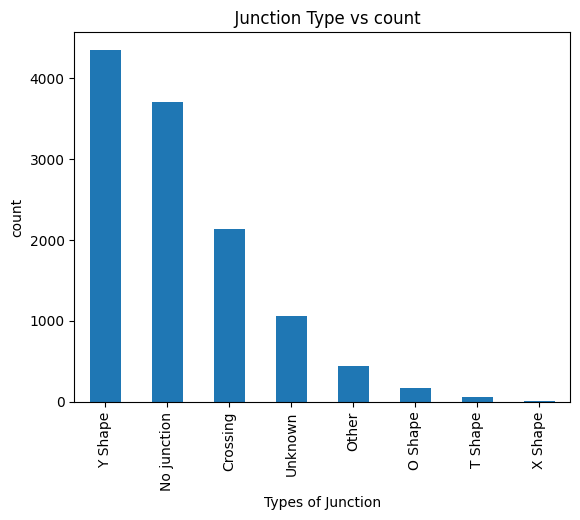

In [29]:
plt.figure()
df['Types_of_Junction'].value_counts().plot(kind='bar')
plt.xlabel("Types of Junction")
plt.ylabel("count")
plt.title("  Junction Type vs count")
plt.show()


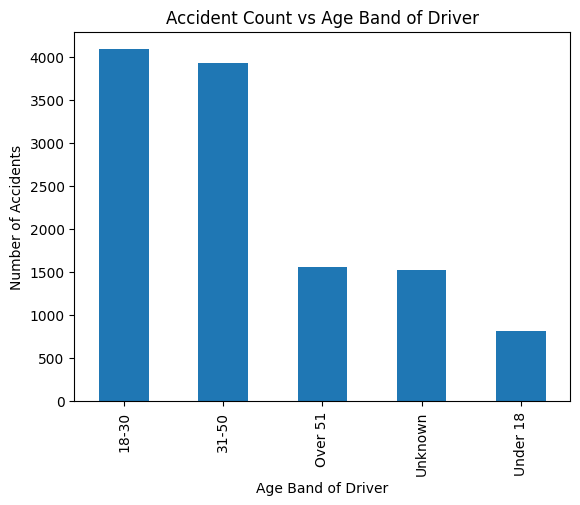

In [30]:
plt.figure()
df['Age_band_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Age Band of Driver")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Age Band of Driver")
plt.show()


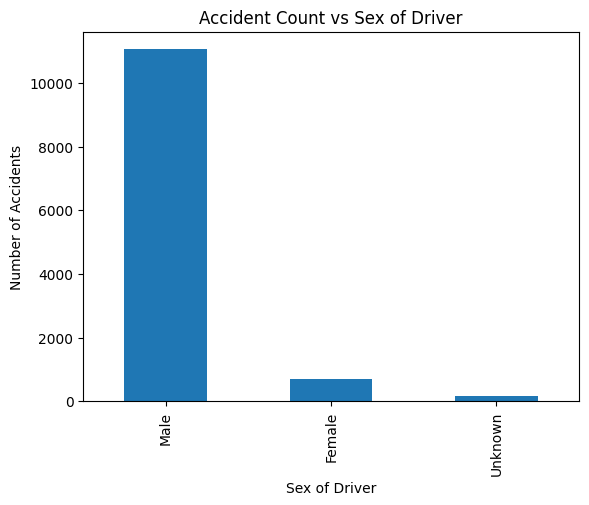

In [31]:
plt.figure()
df['Sex_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Sex of Driver")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Sex of Driver")
plt.show()


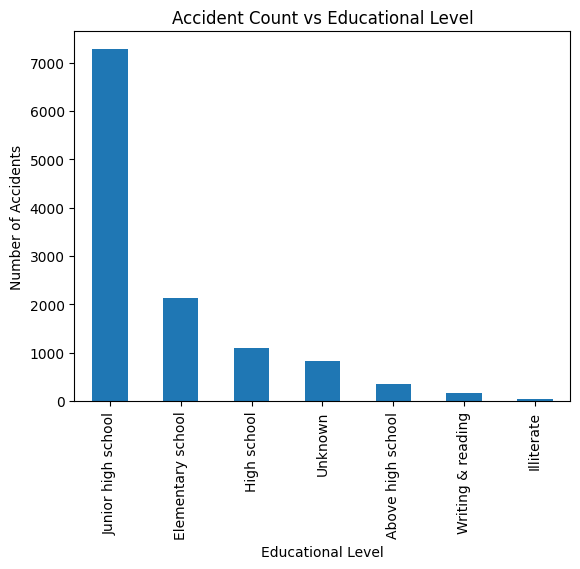

In [32]:
plt.figure()
df['Educational_level'].value_counts().plot(kind='bar')
plt.xlabel("Educational Level")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Educational Level")
plt.show()


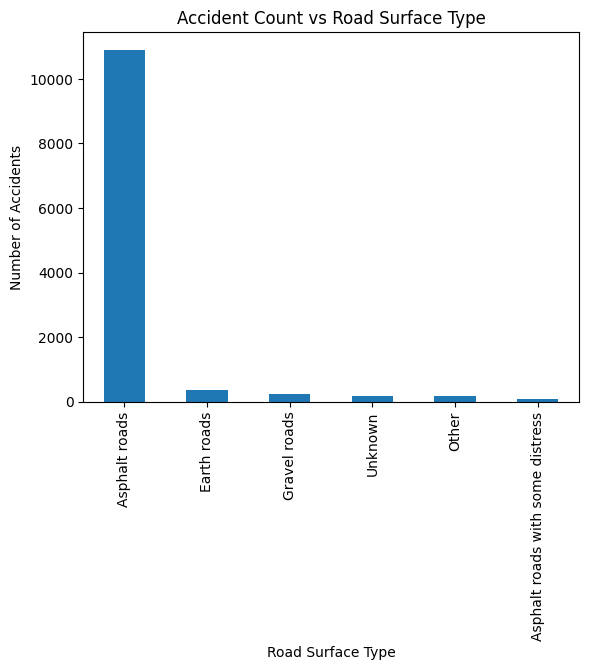

In [33]:
plt.figure()
df['Road_surface_type'].value_counts().plot(kind='bar')
plt.xlabel("Road Surface Type")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Road Surface Type")
plt.show()


In [34]:
df.shape


(11926, 15)

In [35]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col])

In [36]:
print(df.shape)
print(df.dtypes)


(11926, 15)
Age_band_of_driver         object
Sex_of_driver              object
Educational_level          object
Vehicle_driver_relation    object
Driving_experience         object
Lanes_or_Medians           object
Types_of_Junction          object
Road_surface_type          object
Light_conditions           object
Weather_conditions         object
Type_of_collision          object
Vehicle_movement           object
Pedestrian_movement        object
Cause_of_accident          object
Accident_severity           int64
dtype: object


In [37]:
print(df.shape)
print(df.dtypes)


(11926, 15)
Age_band_of_driver         object
Sex_of_driver              object
Educational_level          object
Vehicle_driver_relation    object
Driving_experience         object
Lanes_or_Medians           object
Types_of_Junction          object
Road_surface_type          object
Light_conditions           object
Weather_conditions         object
Type_of_collision          object
Vehicle_movement           object
Pedestrian_movement        object
Cause_of_accident          object
Accident_severity           int64
dtype: object


In [38]:
# ==============================
# CELL 4: Define Target Variable
# ==============================

target_column = "Accident_severity"

print("Target Distribution:")
print(df[target_column].value_counts())


Target Distribution:
Accident_severity
2    10031
1     1737
0      158
Name: count, dtype: int64


In [39]:
# ==============================
# CELL 6: Feature Separation
# ==============================

X = df.drop(columns=[target_column])
y = df[target_column]

num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(exclude=np.number).columns

print("Numerical Features:")
print(num_features)

print("\nCategorical Features:")
print(cat_features)


Numerical Features:
Index([], dtype='str')

Categorical Features:
Index(['Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
       'Vehicle_driver_relation', 'Driving_experience', 'Lanes_or_Medians',
       'Types_of_Junction', 'Road_surface_type', 'Light_conditions',
       'Weather_conditions', 'Type_of_collision', 'Vehicle_movement',
       'Pedestrian_movement', 'Cause_of_accident'],
      dtype='str')


In [41]:
df.dtypes

Age_band_of_driver         object
Sex_of_driver              object
Educational_level          object
Vehicle_driver_relation    object
Driving_experience         object
Lanes_or_Medians           object
Types_of_Junction          object
Road_surface_type          object
Light_conditions           object
Weather_conditions         object
Type_of_collision          object
Vehicle_movement           object
Pedestrian_movement        object
Cause_of_accident          object
Accident_severity           int64
dtype: object

In [42]:
# ==============================
# CELL 7: Continuous Features Only
# ==============================

ordinal_cols = ['Age_band_of_driver', 'Driving_experience']

continuous_cols = [col for col in num_features if col not in ordinal_cols]

print("Continuous Numerical Features for Outlier Detection:")
print(continuous_cols)


Continuous Numerical Features for Outlier Detection:
[]


In [43]:
# ==============================
# CELL 8: IQR Outlier Detection
# ==============================

outlier_summary = []

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append([
        col,
        len(outliers),
        round(len(outliers) / len(df) * 100, 2)
    ])

outlier_df = pd.DataFrame(outlier_summary, 
                          columns=["Feature", "Outlier Count", "Outlier %"])

outlier_df


,Feature,Outlier Count,Outlier %


In [44]:
# Apply IQR-based outlier removal
df_no_outliers = df.copy()

for col in continuous_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]

print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after outlier removal: {df_no_outliers.shape}")
print(f"Rows removed: {df.shape[0] - df_no_outliers.shape[0]}")

Original dataset shape: (11926, 15)
Dataset shape after outlier removal: (11926, 15)
Rows removed: 0


In [45]:
# Boxplot visualization for outlier detection
if len(continuous_cols) > 0:
    fig, axes = plt.subplots(len(continuous_cols), 1, figsize=(8, 3 * len(continuous_cols)))
    
    if len(continuous_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(continuous_cols):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'Boxplot for {col}')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("No continuous numerical features identified for boxplot visualization.")

No continuous numerical features identified for boxplot visualization.


## 6. Feature Engineering and One-Hot Encoding

Nominal categorical features are transformed using one-hot encoding to create binary columns for each category. This approach avoids imposing artificial ordering on nominal variables.

In [ ]:
# Apply one-hot encoding to nominal features
df_encoded = df_no_outliers.copy()

nominal_features = [
    "Sex_of_driver", "Vehicle_driver_relation", "Lanes_or_Medians",
    "Types_of_Junction", "Road_surface_type", "Light_conditions",
    "Weather_conditions", "Type_of_collision", "Vehicle_movement",
    "Pedestrian_movement", "Cause_of_accident", "Educational_level"
]

df_encoded = pd.get_dummies(df_encoded, columns=nominal_features, drop_first=True)

print(f"Shape after one-hot encoding: {df_encoded.shape}")
print(f"\nNew columns added: {df_encoded.shape[1] - df_no_outliers.shape[1]}")
print(f"\nFirst few columns:\n{df_encoded.columns[:20].tolist()}")

Shape after one-hot encoding: (11926, 91)

New columns added: 76

First few columns:
['Age_band_of_driver', 'Driving_experience', 'Accident_severity', 'Sex_of_driver_Male', 'Sex_of_driver_Unknown', 'Vehicle_driver_relation_Other', 'Vehicle_driver_relation_Owner', 'Vehicle_driver_relation_Unknown', 'Lanes_or_Medians_One way', 'Lanes_or_Medians_Two-way (divided with broken lines road marking)', 'Lanes_or_Medians_Two-way (divided with solid lines road marking)', 'Lanes_or_Medians_Undivided Two way', 'Lanes_or_Medians_Unknown', 'Lanes_or_Medians_other', 'Types_of_Junction_No junction', 'Types_of_Junction_O Shape', 'Types_of_Junction_Other', 'Types_of_Junction_T Shape', 'Types_of_Junction_Unknown', 'Types_of_Junction_X Shape']


## 7. Feature Reduction Using Correlation Analysis

Highly correlated features are identified and removed to reduce multicollinearity and improve model performance. Features with correlation greater than a specified threshold with other input features are eliminated, keeping only the target variable unchanged.

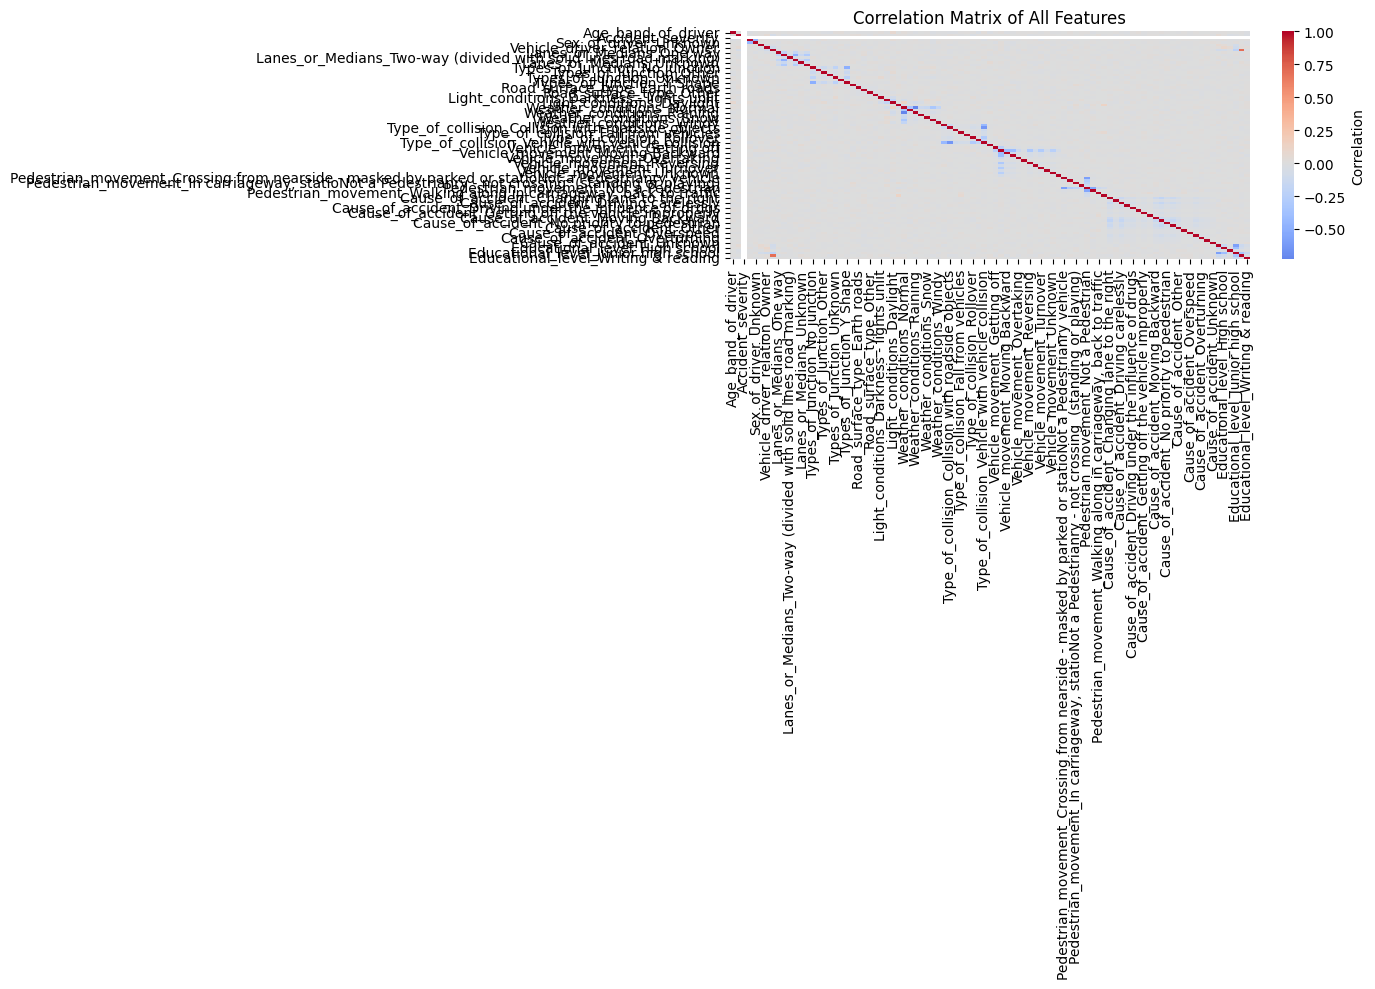

Correlation with Target Variable (Accident_severity):
Age_band_of_driver                     NaN
Driving_experience                     NaN
Accident_severity                      NaN
Sex_of_driver_Male                     NaN
Sex_of_driver_Unknown                  NaN
                                        ..
Educational_level_High school          NaN
Educational_level_Illiterate           NaN
Educational_level_Junior high school   NaN
Educational_level_Unknown              NaN
Educational_level_Writing & reading    NaN
Name: Accident_severity, Length: 91, dtype: float64


In [46]:
# Calculate correlation matrix
correlation_matrix = df_encoded.corr()

# Create visualization of correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

# Find highly correlated features (excluding target)
target = 'Accident_severity'
if target in df_encoded.columns:
    correlation_with_target = correlation_matrix[target].sort_values(ascending=False)
    print("Correlation with Target Variable (Accident_severity):")
    print(correlation_with_target)

In [48]:
# Fix: Ensure only numeric columns are used for descriptive statistics
# Filter quant_df to include only numeric columns
quant_df_numeric = quant_df.select_dtypes(include=["number"])

desc_stats = pd.DataFrame({
    "Mean": quant_df_numeric.mean(),
    "Median": quant_df_numeric.median(),
    "Mode": quant_df_numeric.mode().iloc[0] if not quant_df_numeric.mode().empty else np.nan,
    "Q1": quant_df_numeric.quantile(0.25),
    "Q2": quant_df_numeric.quantile(0.50),
    "Q3": quant_df_numeric.quantile(0.75),
    "Standard Deviation": quant_df_numeric.std()
})

desc_stats

,Mean,Median,Mode,Q1,Q2,Q3,Standard Deviation
Accident_severity,1.827855,2.0,2,2.0,2.0,2.0,0.411123


## 8. Principal Component Analysis (PCA) for Further Feature Reduction

PCA is applied to further reduce the feature space by transforming features into principal components that capture the maximum variance in the data. This technique helps reduce computational complexity while retaining most of the information.

Original number of features: 90
Samples after removing NaN: 9655
Number of PCA components (95% variance): 77
Explained variance ratio: 0.9542


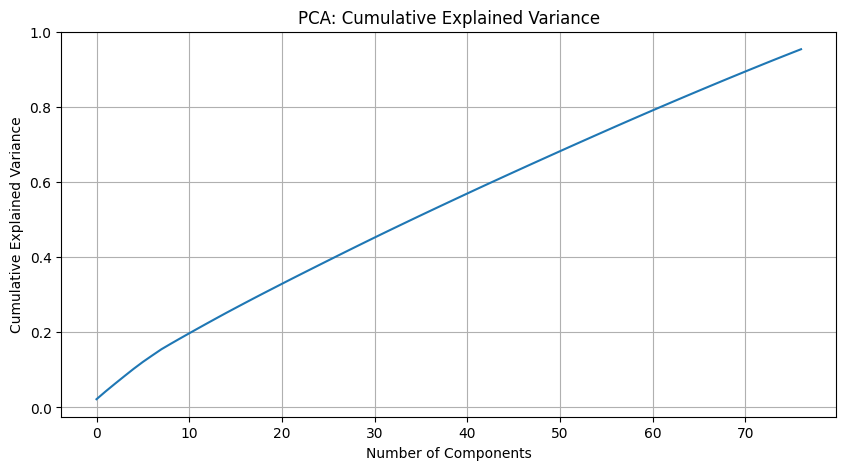


Final dataset shape with PCA: (9655, 78)
PCA dataset ready for model training


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare data for PCA
X_final = df_reduced.drop(columns=['Accident_severity'], errors='ignore')
y_final = df_reduced['Accident_severity'] if 'Accident_severity' in df_reduced.columns else None

# Drop rows with NaN values
X_final_clean = X_final.dropna()
if y_final is not None:
    y_final_clean = y_final.loc[X_final_clean.index]
else:
    y_final_clean = None

# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final_clean)

# Apply PCA to retain 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X_final.shape[1]}")
print(f"Samples after removing NaN: {X_pca.shape[0]}")
print(f"Number of PCA components (95% variance): {pca.n_components_}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# Visualize explained variance
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.grid()
plt.show()

# Create dataframe with PCA components
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
if y_final_clean is not None:
    pca_df['Accident_severity'] = y_final_clean.reset_index(drop=True)

print(f"\nFinal dataset shape with PCA: {pca_df.shape}")
print(f"PCA dataset ready for model training")

## Summary of Data Preprocessing Pipeline

The complete data preprocessing pipeline has been implemented covering the following stages:

1. Missing data identification and basic data exploration
2. Duplicate row detection and removal with unique value verification
3. Ordinal encoding for features with natural ordering (Age, Driving Experience)
4. One-hot encoding for nominal categorical features to avoid artificial ordering
5. Boxplot visualization and IQR-based outlier detection for numerical features
6. Application of IQR method for outlier removal from continuous variables
7. Correlation analysis to identify and remove highly correlated features (threshold: 0.95)
8. Principal Component Analysis to reduce dimensionality while retaining 95% of variance

The processed dataset is now ready for machine learning model training. Two versions are available: the feature-reduced dataset and the PCA-transformed dataset.